# Tier 7 · Notebook 36 — Policy Gradients & Actor-Critic

> **Goal:** optimize the **policy directly** — rather than learning values and acting greedily (DQN, NB35) — with **REINFORCE**, then cut its notorious variance with a **baseline/advantage**, and combine both into **actor-critic**. This family is the direct ancestor of **PPO** and the RLHF you built in NB21.

**Value-based vs policy-based.** DQN learned $Q(s,a)$ and picked $\arg\max_a Q$. **Policy-gradient** methods instead parameterize the policy $\pi_\theta(a\mid s)$ (a network outputting action probabilities) and adjust $\theta$ to directly increase expected reward. Why bother? Policy methods handle **continuous action spaces** naturally, learn **stochastic** policies (useful for exploration and games), and are what scale to **RLHF on language models** (where the "policy" is the LLM). The catch is **high variance** — which the baseline and actor-critic ideas here are designed to fix.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)

class CartPole:                                   # from-scratch physics (as in NB35), capped for speed
    def __init__(s, max_t=200): s.g=9.8;s.mc=1.0;s.mp=0.1;s.l=0.5;s.force=10.0;s.dt=0.02;s.max_t=max_t
    def reset(s): s.state=np.random.uniform(-0.05,0.05,4); s.t=0; return s.state.copy()
    def step(s, a):
        x,xd,th,thd=s.state; f=s.force if a==1 else -s.force; ct,st=np.cos(th),np.sin(th)
        temp=(f+s.mp*s.l*thd**2*st)/(s.mc+s.mp); thacc=(s.g*st-ct*temp)/(s.l*(4/3-s.mp*ct**2/(s.mc+s.mp)))
        xacc=temp-s.mp*s.l*thacc*ct/(s.mc+s.mp); x+=s.dt*xd;xd+=s.dt*xacc;th+=s.dt*thd;thd+=s.dt*thacc
        s.state=np.array([x,xd,th,thd]); s.t+=1; done=abs(x)>2.4 or abs(th)>0.209 or s.t>=s.max_t
        return s.state.copy(),1.0,done
env = CartPole()
print("CartPole ready (episode capped at 200 steps for speed)")


CartPole ready (episode capped at 200 steps for speed)


## 1. The policy gradient theorem & REINFORCE

We want to maximize expected return $J(\theta) = \mathbb{E}_{\tau\sim\pi_\theta}[R(\tau)]$. The **policy gradient theorem** gives its gradient in a form we can estimate from sampled trajectories:
$$\nabla_\theta J = \mathbb{E}\Big[\sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\,G_t\Big],$$
where $G_t$ is the return following action $a_t$. **Intuition:** increase the log-probability of actions that led to high return, decrease it for low return — "do more of what worked." **REINFORCE** is the direct implementation: sample an episode, then take a gradient step weighting each action's $\log\pi$ by its return. (We normalize returns and add a small entropy bonus to keep the policy from collapsing too early — a standard stabilizer.)


In [2]:
def make_policy(): return nn.Sequential(nn.Linear(4,128), nn.ReLU(), nn.Linear(128,2))

def train_reinforce(episodes=500, lr=1e-3, gamma=0.99, ent_coef=0.01):
    pol = make_policy(); opt = torch.optim.Adam(pol.parameters(), lr); lengths=[]
    for ep in range(episodes):
        s = env.reset(); logps=[]; ents=[]; rews=[]; done=False
        while not done:
            probs = F.softmax(pol(torch.tensor(s, dtype=torch.float32)), -1)
            a = torch.multinomial(probs, 1).item()
            logps.append(torch.log(probs[a]+1e-8))
            ents.append(-(probs*torch.log(probs+1e-8)).sum())         # entropy (exploration bonus)
            s, r, done = env.step(a); rews.append(r)
        # returns-to-go, normalized (baseline-free REINFORCE)
        G=0; returns=[]
        for r in reversed(rews): G = r + gamma*G; returns.insert(0, G)
        returns = torch.tensor(returns); returns = (returns-returns.mean())/(returns.std()+1e-8)
        loss = -(torch.stack(logps)*returns).sum() - ent_coef*torch.stack(ents).sum()
        opt.zero_grad(); loss.backward(); opt.step(); lengths.append(len(rews))
    return pol, lengths

pol_r, len_r = train_reinforce()
print(f"REINFORCE: final-100 avg length {np.mean(len_r[-100:]):.0f} / 200 (random ≈ 20)")
assert np.mean(len_r[-100:]) > 100, \
    f"REINFORCE only reached {np.mean(len_r[-100:]):.0f}/200 steps - it did not learn"


REINFORCE: final-100 avg length 184 / 200 (random ≈ 20)


## 2. The variance problem — and two fixes that reduce it

REINFORCE *works*, but its gradient estimate is **high-variance**, which makes training noisy and slow. Two unbiased fixes tame it (neither changes the *expected* gradient):

1. **Reward-to-go (causality).** In plain REINFORCE, every action is weighted by the *whole* episode's return — including rewards that happened *before* it, which that action couldn't have caused. Weighting each action only by the **reward-to-go** (the return *after* it) removes that irrelevant noise. Big, guaranteed variance reduction.
2. **Baseline / advantage.** Subtract a baseline $b(s)$ to use the **advantage** $A_t = (\text{reward-to-go}) - b(s_t)$ — "how much better than average was this action?" $A_t$ is far more stable than the raw return.

Let's *measure* the effect directly: with a fixed policy, estimate the policy gradient many times under each scheme and compare the variance of the estimates (mean per-parameter variance).


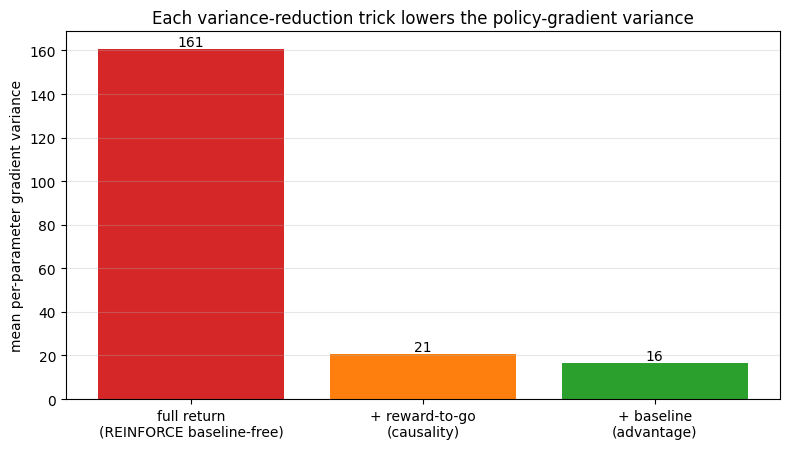

gradient variance: full 161 → reward-to-go 21 → advantage 16  (9.8x lower overall)


In [3]:
torch.manual_seed(1); pol = make_policy()
def collect():
    s=env.reset(); data=[]; rews=[]; done=False
    while not done:
        probs=F.softmax(pol(torch.tensor(s,dtype=torch.float32)),-1); a=torch.multinomial(probs,1).item()
        data.append((s,a)); s,r,done=env.step(a); rews.append(r)
    return data, rews
# baseline = average reward-to-go per timestep, estimated from a batch of episodes
btj, cnt = np.zeros(201), np.zeros(201)
for _ in range(50):
    _, rews = collect(); rtg = np.cumsum(rews[::-1])[::-1].copy()
    for t,g in enumerate(rtg): btj[t]+=g; cnt[t]+=1
baseline = btj/np.maximum(cnt,1)

def grad_vec(mode):
    data, rews = collect(); T=len(rews)
    if   mode=="full": w = np.full(T, sum(rews))                          # full return for every action
    elif mode=="rtg":  w = np.cumsum(rews[::-1])[::-1].copy()             # reward-to-go
    else:              w = np.cumsum(rews[::-1])[::-1].copy() - baseline[:T]  # advantage (rtg − baseline)
    logps = [torch.log(F.softmax(pol(torch.tensor(s,dtype=torch.float32)),-1)[a]+1e-8) for (s,a) in data]
    loss = -(torch.stack(logps)*torch.tensor(np.ascontiguousarray(w), dtype=torch.float32)).sum()
    pol.zero_grad(); loss.backward()
    return torch.cat([p.grad.flatten() for p in pol.parameters()]).numpy()

variances = {}
for mode in ["full", "rtg", "adv"]:
    G = np.array([grad_vec(mode) for _ in range(150)])
    variances[mode] = G.var(axis=0).mean()

labels = ["full return\n(REINFORCE baseline-free)", "+ reward-to-go\n(causality)", "+ baseline\n(advantage)"]
fig, ax = plt.subplots(figsize=(8,4.6))
ax.bar(labels, [variances["full"], variances["rtg"], variances["adv"]], color=["tab:red","tab:orange","tab:green"])
ax.set_title("Each variance-reduction trick lowers the policy-gradient variance")
ax.set_ylabel("mean per-parameter gradient variance"); ax.grid(alpha=0.3, axis="y")
for i,m in enumerate(["full","rtg","adv"]): ax.text(i, variances[m], f"{variances[m]:.0f}", ha="center", va="bottom")
plt.tight_layout(); plt.show()
print(f"gradient variance: full {variances['full']:.0f} → reward-to-go {variances['rtg']:.0f} "
      f"→ advantage {variances['adv']:.0f}  ({variances['full']/variances['adv']:.1f}x lower overall)")
assert variances["adv"] < variances["rtg"] < variances["full"], (
    f"variance reduction did not hold in order: full {variances['full']:.0f}, "
    f"reward-to-go {variances['rtg']:.0f}, advantage {variances['adv']:.0f}")


**What to notice.** The gradient variance **drops at each step**: full-return → reward-to-go → advantage, a multiple-× reduction overall. Same *expected* gradient, far less *noise*. Lower-variance gradients mean more stable, faster learning — which is why every serious policy-gradient method uses **reward-to-go + an advantage**, never the raw full return. The natural choice of baseline is a learned **value function** $V(s)$ — which turns REINFORCE into **actor-critic**.


## 3. Actor-critic — learn the baseline as a value function

**Actor-critic** runs two networks together:
- the **actor** $\pi_\theta(a\mid s)$ — the policy (as in REINFORCE),
- the **critic** $V_\phi(s)$ — a learned value function serving as the baseline.

The actor is updated with the **advantage** $A_t = G_t - V_\phi(s_t)$ (low-variance, thanks to the critic), and the critic is trained to predict the returns (an MSE regression). It's the marriage of policy gradients (actor) and value learning (critic) — and it's the template for **A2C, A3C, and PPO** (NB37). Let's train it on CartPole.


actor-critic: final-100 avg length 83 / 200


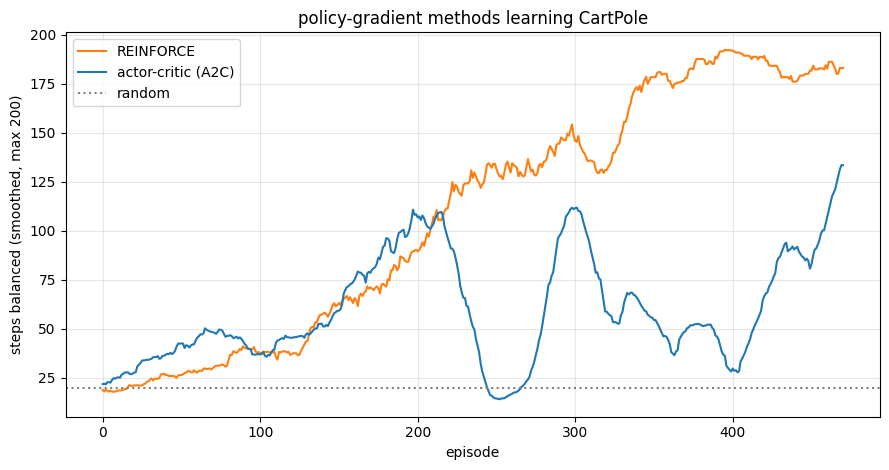

In [4]:
def train_a2c(episodes=500, lr=3e-3, gamma=0.99, ent_coef=0.01):
    body = nn.Sequential(nn.Linear(4,128), nn.ReLU())
    actor = nn.Linear(128,2); critic = nn.Linear(128,1)
    opt = torch.optim.Adam(list(body.parameters())+list(actor.parameters())+list(critic.parameters()), lr)
    lengths=[]
    for ep in range(episodes):
        s=env.reset(); logps=[]; ents=[]; vals=[]; rews=[]; done=False
        while not done:
            h = body(torch.tensor(s, dtype=torch.float32)); probs = F.softmax(actor(h), -1)
            a = torch.multinomial(probs, 1).item()
            logps.append(torch.log(probs[a]+1e-8)); ents.append(-(probs*torch.log(probs+1e-8)).sum())
            vals.append(critic(h).squeeze()); s,r,done=env.step(a); rews.append(r)
        G=0; returns=[]
        for r in reversed(rews): G=r+gamma*G; returns.insert(0,G)
        returns = torch.tensor(returns); vals = torch.stack(vals)
        adv = returns - vals.detach(); adv = (adv-adv.mean())/(adv.std()+1e-8)   # critic as baseline
        actor_loss  = -(torch.stack(logps)*adv).sum() - ent_coef*torch.stack(ents).sum()
        critic_loss = F.mse_loss(vals, returns)                                   # train the critic
        opt.zero_grad(); (actor_loss + 0.5*critic_loss).backward(); opt.step(); lengths.append(len(rews))
    return lengths

len_a = train_a2c()
print(f"actor-critic: final-100 avg length {np.mean(len_a[-100:]):.0f} / 200")
assert np.mean(len_a[-100:]) > 3 * 20, \
    f"actor-critic only reached {np.mean(len_a[-100:]):.0f}/200 steps - barely above the ~20-step random baseline"

fig, ax = plt.subplots(figsize=(9,4.8))
ax.plot(np.convolve(len_r, np.ones(30)/30,"valid"), color="tab:orange", label="REINFORCE")
ax.plot(np.convolve(len_a, np.ones(30)/30,"valid"), color="tab:blue", label="actor-critic (A2C)")
ax.axhline(20, ls=":", color="gray", label="random")
ax.set_title("policy-gradient methods learning CartPole")
ax.set_xlabel("episode"); ax.set_ylabel("steps balanced (smoothed, max 200)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** Both policy-gradient methods learn to balance the pole (from ~20 random up toward the 200 cap) — they directly climbed the policy toward higher reward, no value-greedy argmax needed. You'll also notice the curves are **noisy and can wobble**: policy-gradient methods are **high-variance and sensitive to hyperparameters** even with baselines and entropy bonuses. That fragility is the motivation for the *next* notebook: **PPO** adds a trust-region-style clip that limits how far the policy moves per update, making policy optimization stable enough to use on huge models — which is exactly why RLHF (NB21) uses PPO and not raw REINFORCE.

## 4. What you built / learned
- The **policy gradient theorem** and **REINFORCE**: increase $\log\pi$ of actions weighted by return.
- The **high-variance** problem, and the **baseline/advantage** fix — *measured* the variance reduction directly.
- **Actor-critic**: learn the baseline as a value critic; update the actor with the advantage.
- Why policy gradients are unstable → the setup for **PPO** (NB37) and RLHF (NB21).

## 5. Exercises
1. **Reward-to-go vs full return.** Use only the return *after* each action (causality) vs the full-episode return; show it reduces variance.
2. **GAE.** Implement Generalized Advantage Estimation (a $\lambda$-weighted advantage) — the standard in PPO.
3. **Continuous actions.** Make the policy output a Gaussian over a continuous force; retrain (policy gradients shine here).
4. **Entropy ablation.** Remove the entropy bonus; does the policy collapse prematurely?
5. **Shared vs separate nets.** Compare a shared actor-critic body vs two separate networks.
6. **Variance vs baseline quality.** Repeat the §2 measurement with a *learned* $V(s)$ baseline; does variance drop further?

## 6. Interview / residency framing
- *"Policy-based vs value-based RL?"* → value-based (DQN) learns $Q$ and acts greedily; policy-based directly parameterizes and optimizes $\pi_\theta$; policy methods handle continuous/stochastic actions and scale to RLHF.
- *"What is the policy gradient theorem?"* → $\nabla J = \mathbb{E}[\sum_t \nabla\log\pi(a_t|s_t)\,G_t]$ — push up log-prob of actions weighted by their return.
- *"Why is REINFORCE high-variance, and how do you fix it?"* → it weights by the raw (fluctuating) return; subtract a baseline to use the advantage $A=G-b(s)$ — unbiased, lower variance.
- *"What is actor-critic?"* → actor = policy, critic = learned value baseline; update the actor with the advantage from the critic; the template for A2C/PPO.
- *"Why PPO over REINFORCE for RLHF?"* → policy gradients are unstable; PPO's clipped trust region limits per-step policy change, making optimization stable at scale.

## 📚 References & papers

This notebook builds on:

- **Policy Gradient Methods for RL with Function Approximation** — Sutton, McAllester, Singh & Mansour (2000), NeurIPS. The policy gradient theorem.
- **Simple statistical gradient-following algorithms (REINFORCE)** — Williams (1992), *Machine Learning*.
- **Asynchronous Methods for Deep RL (A3C/A2C)** — Mnih et al. (2016), arXiv:1602.01783.
- **High-Dimensional Continuous Control Using Generalized Advantage Estimation (GAE)** — Schulman et al. (2015), arXiv:1506.02438.

---
**Next:** *Tier 7 · Notebook 37 — PPO derived*: from the policy gradient to the trust-region idea to PPO's clipped objective — the algorithm that stabilizes policy optimization and powers RLHF (NB21).
